# Personalization Impact — Reactivation Analysis for Long-Dormant Clients (Attribution-Window Method)

## What this notebook answers

For clients who haven't checked out in 3+ years, does the *type* of email/push campaign they receive relate to whether they come back and buy something? Specifically: do personalized (APEC) sends show a meaningfully different reactivation rate than everything else?

This is an **observational comparison of existing send history** — it does not involve any new experiment or randomization. It tells us what's *associated* with reactivation historically, which is useful context on its own and also as a sanity check before committing to any further test.

The analysis has two parts:
1. **APEC vs. non-APEC** — the primary comparison, since APEC is the specific personalization system in question. Transactional/account-service email (see categories below) is excluded from both sides of this comparison, since it isn't a marketing choice that could be "personalized or not."
2. **A category breakdown** — APEC alongside several other send types (DSE, TFY, a dormant-specific browse-abandon trigger, one "New For You" campaign, one "Fresh Picks" campaign, transactional/account-service email, and everything else) — for additional context on where reactivation is and isn't happening.

Both parts look at over a year of send history rather than a shorter window — several of these categories are a small share of total volume, and a shorter window doesn't give them enough sends to read a reliable rate from.

## Population: clients dormant for 3+ years

We restrict to clients with no checkout in more than **1,095 days (3 years)**. This is deliberately a stricter cut than StitchFix's standard "Dormant" bucket (any checkout gap over 365 days) — for a personalization system that relies on a history of client behavior, a client who hasn't interacted with the product in years is the population where that history (and therefore the personalization itself) is most likely to be stale or unavailable. That makes this group the most informative place to check whether personalization is pulling its weight.

## Campaign categories: how sends are classified

Campaigns are classified from the sent campaign's name (`send_utm_campaign` on the Blueshift send data), using pattern matching rather than a verified per-send flag, since no such flag exists in the data available. The categories, in the order they're applied (a send is assigned to the first category it matches):

| Category | What it captures |
|---|---|
| **APEC** | Any campaign name containing "apec" — the personalization system this analysis is centered on. Cross-checked against a reference list of APEC job configurations; naming is consistent between the two. |
| **TRANSACTIONAL** | Any campaign name containing "transactional" — account-service email (password resets, order/Fix status confirmations, account alerts, and similar) that a client only receives because they're already taking an action on their account. A client can't be sent one of these "instead of" a marketing email the way they can for a real campaign choice, so it's excluded entirely from Part 1's APEC/non-APEC comparison, and shown only as its own category in Part 2 for transparency — not as a marketing lever to rank against the others. |
| **DSE** | Campaign names containing "dse", generally attached to otherwise-standard marketing sends. |
| **TFY** | Campaign names containing "tfy" (appears to stand for "trending/top for you"), not already captured under DSE. |
| **dormantbrowseabandon** | A trigger campaign specifically aimed at dormant clients who browsed the site without buying. |
| **newforyou** | A single static "New For You" campaign, sent once in January 2026. |
| **freshpicks** | A single "Fresh Picks" push campaign, sent once in July 2025. |
| **OTHER** | Everything else — the large majority of remaining send volume, made up of generic marketing, seasonal, and win-back campaigns with no personalization-suggestive naming. |

**Important caveats:**
- DSE, TFY, newforyou, and freshpicks are grouped separately because their names *suggest* some form of dynamic or "for you" content, but this cannot be confirmed to reflect genuine per-client, embedding-driven personalization the way APEC can — they may just be marketing copy/branding with no actual personalization behind them. The APEC vs. non-APEC comparison in Part 1 is the one with a confirmed, verifiable classification.
- TRANSACTIONAL is different in kind from every other category here: it isn't a marketing send at all, so a high reactivation rate on it reflects a client's own already-in-progress return (e.g. resetting a password to log back in, or checking an order they already placed) rather than something the send itself caused. Its rate should not be read as a "top-performing campaign type."

## Reactivation metric: attribution window

A client is counted as **reactivated** by a send if a Fix request or a direct-buy order was created within a short, fixed window after the send — captured by the `fix_flag` and `direct_buy_flag` columns already computed on `blueshift.campaign_activity_kpis` (attribution window: 2 days after the send).

This is a **broader, less strict standard** than requiring evidence the client actually opened or clicked the send — it counts any qualifying purchase event that lands in the window, regardless of the channel that drove it. The tradeoff runs the opposite direction of a click-through-based metric: it won't miss reactivations that happen through untracked paths (no session/click evidence required), but it can count a coincidental, unrelated purchase that happened to land in the same 2-day window as a "reactivation" it wasn't actually caused by. Observed rates here should be read as an upper-bound-leaning estimate, for the same reason a click-through-only metric reads as a lower bound.

**Data recency:** `fix_flag`/`direct_buy_flag` are corrected/backfilled by the upstream pipeline for a period after the send, and are only guaranteed final once that window has fully elapsed — confirmed directly with the team that owns this pipeline: **45 days**. This analysis excludes any send more recent than that, so every rate reported here is final, not still-settling.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from amphibian import get_data_accessor
from statsmodels.stats.proportion import proportion_confint, confint_proportions_2indep, test_proportions_2indep

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)

def query(sql):
    return get_data_accessor(engines=['presto']).fetch_sql(sql=sql, error_on_empty=False)

# Population thresholds (days since last checkout)
ACTIVE_MAX_DAYS = 120
LAPSED_MAX_DAYS = 365
DORMANT_3YR_MIN_DAYS = 1095  # the population this analysis focuses on

# Send history window
START_DATE = '2025-01-01'  # a bit over a year of history, so the thinner campaign categories have enough volume to read
END_DATE = '2026-05-31'  # hardcoded for idempotent results -- last day of a full month, so no partial month
                         # sneaks into the monthly charts. Safely past the confirmed 45-day maturity window

# Statistics
ALPHA = 0.05

# Chart colors -- one fixed hue per category, used consistently across every chart in this notebook
CATEGORY_COLORS = {
    'non-APEC':             '#2a78d6',  # blue
    'APEC':                 '#e34948',  # red
    'OTHER':                '#eda100',  # yellow
    'TRANSACTIONAL':        '#7a7a7a',  # grey -- not a marketing category, kept visually distinct
    'DSE':                  '#008300',  # green
    'TFY':                  '#e87ba4',  # magenta
    'freshpicks':           '#2a78d6',  # blue
    'newforyou':            '#1baf7a',  # aqua
    'dormantbrowseabandon': '#eb6834',  # orange
}

print(f"Analysis window: {START_DATE} to {END_DATE}")

Analysis window: 2025-01-01 to 2026-05-31


## Step 1 — How many clients are we talking about?

Before comparing campaign types, a quick sanity check on the population itself: how many clients fall into each lifecycle bucket, and specifically, how large is the Dormant 3+ years group this analysis focuses on.

In [2]:
lifecycle_bucket_query = f"""--sql
WITH journal AS (
    SELECT
        client_id,
        client_state_detail,
        date_diff('day', date(last_buyable_checkout_ts), current_date) AS days_since_last_checkout
    FROM curated.checkout_based_client_state_journal
    WHERE is_current = 1
)
SELECT
    CASE
        WHEN client_state_detail = 'Never Active' THEN 'Never Active'
        WHEN days_since_last_checkout <= {ACTIVE_MAX_DAYS} THEN 'Active'
        WHEN days_since_last_checkout <= {LAPSED_MAX_DAYS} THEN 'Lapsed'
        WHEN days_since_last_checkout <= {DORMANT_3YR_MIN_DAYS} THEN 'Dormant'
        ELSE 'Dormant 3+ yrs'
    END AS lifecycle_bucket,
    COUNT(*) AS n_clients
FROM journal
GROUP BY 1
ORDER BY n_clients DESC
"""

lifecycle_bucket_df = query(lifecycle_bucket_query)
lifecycle_bucket_df

/Users/sergio.oyola/.pyenv/versions/3.9.13/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


,lifecycle_bucket,n_clients
0,Never Active,36869411
1,Dormant 3+ yrs,9808734
2,Dormant,2101175
3,Active,1463269
4,Lapsed,869323


## Step 2 — The shared logic behind both parts

Both Part 1 and Part 2 below follow the same three-step logic, just grouped differently (binary APEC/non-APEC vs. the full category breakdown):

1. **Find eligible sends**: sends to clients who were already Dormant 3+ years *at the time of the send* (not just today — a client's status is checked against their state as of that specific send).
2. **Categorize each send** by its campaign name, per the categories described above.
3. **Read the reactivation flag**: `fix_flag = 1 OR direct_buy_flag = 1`, already computed upstream with a 2-day attribution window.

Each client is counted once per group (e.g., once for APEC, once for non-APEC, if they received both) — a client who received multiple sends in the same group is only counted as reactivated once, not once per send.

## Part 1 — APEC vs. non-APEC

The primary comparison: does receiving an APEC (personalized) send relate to a different reactivation rate than receiving anything else? Transactional/account-service email is excluded from the population for this comparison (see the category table above) — it isn't a marketing choice, so it doesn't belong on either side of an APEC-vs-non-APEC split.

In [3]:
apec_split_query = f"""--sql
WITH sends AS (
    SELECT
        client_id,
        sent_timestamp,
        send_utm_campaign,
        CASE WHEN fix_flag = 1 OR direct_buy_flag = 1 THEN 1 ELSE 0 END AS reactivated
    FROM blueshift.campaign_activity_kpis
    WHERE execution_date >= DATE '{START_DATE}'
      AND execution_date <= DATE '{END_DATE}'
      AND holdout_group = 0 -- only include clients who were actually sent the campaign, not just targeted
      AND send_utm_campaign NOT LIKE '%transactional%' -- exclude account-service email (password resets, order/Fix status, etc.); a client only gets these because they're already returning on their own, not because of a marketing choice, so they don't belong on either side of this comparison
),
dormant_3yr_sends AS (
    -- client must already be Dormant 3+ years AS OF the send, not just today
    SELECT s.client_id, s.sent_timestamp, s.send_utm_campaign, s.reactivated
    FROM sends s
    INNER JOIN curated.checkout_based_client_state_journal j
        ON s.client_id = j.client_id
        AND s.sent_timestamp >= j.start_timestamp
        AND s.sent_timestamp <  j.end_timestamp
    WHERE j.client_state_detail = 'Dormant'
      AND date_diff('day', date(j.last_buyable_checkout_ts), date(s.sent_timestamp)) > {DORMANT_3YR_MIN_DAYS}
),
categorized_sends AS (
    SELECT
        client_id, sent_timestamp, reactivated,
        CASE WHEN send_utm_campaign LIKE '%apec%' THEN 'APEC' ELSE 'non-APEC' END AS apec_group
    FROM dormant_3yr_sends
),
client_group AS (
    -- one row per client per group: did they reactivate at all under this group
    SELECT
        client_id,
        apec_group,
        MAX(reactivated) AS client_reactivated
    FROM categorized_sends
    GROUP BY 1, 2
)
SELECT
    apec_group,
    COUNT(DISTINCT client_id) AS unique_clients_sent,
    SUM(client_reactivated) AS reactivated_clients,
    CAST(SUM(client_reactivated) AS DOUBLE) / COUNT(DISTINCT client_id) AS client_reactivation_rate
FROM client_group
GROUP BY 1
ORDER BY unique_clients_sent DESC
"""

apec_split_df = query(apec_split_query)
apec_split_df

/Users/sergio.oyola/.pyenv/versions/3.9.13/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


,apec_group,unique_clients_sent,reactivated_clients,client_reactivation_rate
0,non-APEC,4311084,94686,0.021963
1,APEC,1322312,15865,0.011998


A raw rate comparison isn't enough on its own. The next cell adds a confidence interval on each rate individually, plus a formal test on the *difference* between APEC and non-APEC, so "is there a real difference here" has an actual answer rather than just eyeballing two numbers.

In [4]:
apec_row = apec_split_df[apec_split_df['apec_group'] == 'APEC'].iloc[0]
non_apec_row = apec_split_df[apec_split_df['apec_group'] == 'non-APEC'].iloc[0]

apec_ci = proportion_confint(apec_row['reactivated_clients'], apec_row['unique_clients_sent'], alpha=ALPHA, method='wilson')
non_apec_ci = proportion_confint(non_apec_row['reactivated_clients'], non_apec_row['unique_clients_sent'], alpha=ALPHA, method='wilson')

diff = non_apec_row['client_reactivation_rate'] - apec_row['client_reactivation_rate']
diff_ci = confint_proportions_2indep(
    non_apec_row['reactivated_clients'], non_apec_row['unique_clients_sent'],
    apec_row['reactivated_clients'], apec_row['unique_clients_sent'],
    compare='diff', method='wald', alpha=ALPHA,
)
test_result = test_proportions_2indep(
    non_apec_row['reactivated_clients'], non_apec_row['unique_clients_sent'],
    apec_row['reactivated_clients'], apec_row['unique_clients_sent'],
    compare='diff', method='wald',
)

print(f"APEC:      {apec_row['client_reactivation_rate']:.4%}  (95% CI: {apec_ci[0]:.4%} - {apec_ci[1]:.4%}, n={apec_row['unique_clients_sent']:,})")
print(f"non-APEC:  {non_apec_row['client_reactivation_rate']:.4%}  (95% CI: {non_apec_ci[0]:.4%} - {non_apec_ci[1]:.4%}, n={non_apec_row['unique_clients_sent']:,})")
print()
print(f"Difference (non-APEC minus APEC): {diff:.4%}  (95% CI: {diff_ci[0]:.4%} - {diff_ci[1]:.4%})")
print(f"p-value: {test_result.pvalue:.2e}")

APEC:      1.1998%  (95% CI: 1.1814% - 1.2185%, n=1,322,312)
non-APEC:  2.1963%  (95% CI: 2.1825% - 2.2102%, n=4,311,084)

Difference (non-APEC minus APEC): 0.9965%  (95% CI: 0.9734% - 1.0197%)
p-value: 0.00e+00


**How to read this:** if the confidence interval on the difference doesn't cross zero, the gap between APEC and non-APEC is unlikely to be due to chance alone, given this data. That said, this is an observational comparison, not a randomized test — APEC and non-APEC sends may differ in other ways too (which clients get targeted, how often, through which channel), so a statistically significant gap here reflects an association, not necessarily that removing personalization *causes* a change in reactivation.

### APEC vs. non-APEC, month by month

The comparison above pools the whole window into one number per group. It's worth also looking at this broken out by month — a pooled gap that's actually driven by one or two unusual months would be a much weaker basis for a conclusion than a gap that shows up consistently over time.

In [5]:
apec_monthly_query = f"""--sql
WITH sends AS (
    SELECT
        client_id,
        sent_timestamp,
        send_utm_campaign,
        CASE WHEN fix_flag = 1 OR direct_buy_flag = 1 THEN 1 ELSE 0 END AS reactivated
    FROM blueshift.campaign_activity_kpis
    WHERE execution_date >= DATE '{START_DATE}'
      AND execution_date <= DATE '{END_DATE}'
      AND holdout_group = 0
      AND send_utm_campaign NOT LIKE '%transactional%' -- exclude account-service email; see Part 1's intro cell for why
),
dormant_3yr_sends AS (
    SELECT s.client_id, s.sent_timestamp, s.send_utm_campaign, s.reactivated
    FROM sends s
    INNER JOIN curated.checkout_based_client_state_journal j
        ON s.client_id = j.client_id
        AND s.sent_timestamp >= j.start_timestamp
        AND s.sent_timestamp <  j.end_timestamp
    WHERE j.client_state_detail = 'Dormant'
      AND date_diff('day', date(j.last_buyable_checkout_ts), date(s.sent_timestamp)) > {DORMANT_3YR_MIN_DAYS}
),
categorized_sends AS (
    SELECT
        client_id, sent_timestamp, reactivated,
        CASE WHEN send_utm_campaign LIKE '%apec%' THEN 'APEC' ELSE 'non-APEC' END AS apec_group
    FROM dormant_3yr_sends
),
client_month_group AS (
    -- one row per client per month per group: did they reactivate at all that month, under this group
    SELECT
        client_id,
        DATE_TRUNC('month', sent_timestamp) AS month,
        apec_group,
        MAX(reactivated) AS client_reactivated
    FROM categorized_sends
    GROUP BY 1, 2, 3
)
SELECT
    month,
    apec_group,
    COUNT(DISTINCT client_id) AS unique_clients_sent,
    SUM(client_reactivated) AS reactivated_clients,
    CAST(SUM(client_reactivated) AS DOUBLE) / COUNT(DISTINCT client_id) AS client_reactivation_rate
FROM client_month_group
GROUP BY 1, 2
ORDER BY 1, 2
"""

apec_monthly_df = query(apec_monthly_query)
apec_monthly_df['month'] = pd.to_datetime(apec_monthly_df['month'])
apec_monthly_df.head()

/Users/sergio.oyola/.pyenv/versions/3.9.13/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


,month,apec_group,unique_clients_sent,reactivated_clients,client_reactivation_rate
0,2025-01-01,APEC,875027,1737,0.001985
1,2025-01-01,non-APEC,1456308,6369,0.004373
2,2025-02-01,APEC,878809,1605,0.001826
3,2025-02-01,non-APEC,3094051,5634,0.001821
4,2025-03-01,APEC,880369,1735,0.001971


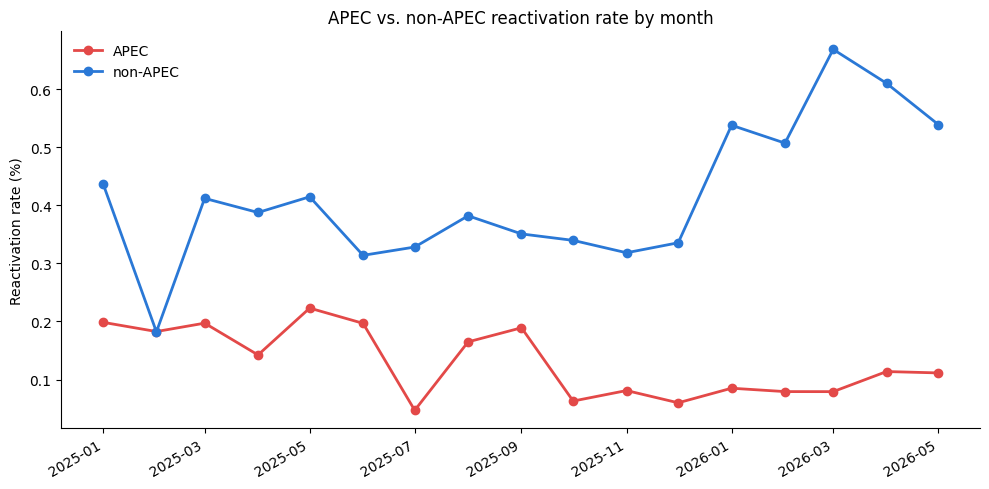

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

for group_name, group_df in apec_monthly_df.groupby('apec_group'):
    group_df = group_df.sort_values('month')
    ax.plot(
        group_df['month'], group_df['client_reactivation_rate'] * 100,
        marker='o', markersize=6, linewidth=2,
        color=CATEGORY_COLORS[group_name], label=group_name,
    )

ax.set_ylabel('Reactivation rate (%)')
ax.set_xlabel('')
ax.set_title('APEC vs. non-APEC reactivation rate by month')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Part 2 — Full category breakdown

The same logic, now split into all eight campaign categories instead of a binary APEC/non-APEC split. This is meant as descriptive context — showing where reactivation is concentrated across different send types — rather than a second formal hypothesis test. With eight groups, testing every pair would need a multiple-comparison correction; Part 1 already covers the primary, decision-relevant comparison. Unlike Part 1, this breakdown keeps transactional/account-service email as its own labeled category rather than excluding it, so its (very different) rate is visible rather than hidden — but see the category table above for why it shouldn't be read as a real marketing lever.

In [7]:
category_query = f"""--sql
WITH sends AS (
    SELECT
        client_id,
        sent_timestamp,
        send_utm_campaign,
        CASE WHEN fix_flag = 1 OR direct_buy_flag = 1 THEN 1 ELSE 0 END AS reactivated
    FROM blueshift.campaign_activity_kpis
    WHERE execution_date >= DATE '{START_DATE}'
      AND execution_date <= DATE '{END_DATE}'
      AND holdout_group = 0
),
dormant_3yr_sends AS (
    -- client must already be Dormant 3+ years AS OF the send, not just today
    SELECT s.client_id, s.sent_timestamp, s.send_utm_campaign, s.reactivated
    FROM sends s
    INNER JOIN curated.checkout_based_client_state_journal j
        ON s.client_id = j.client_id
        AND s.sent_timestamp >= j.start_timestamp
        AND s.sent_timestamp <  j.end_timestamp
    WHERE j.client_state_detail = 'Dormant'
      AND date_diff('day', date(j.last_buyable_checkout_ts), date(s.sent_timestamp)) > {DORMANT_3YR_MIN_DAYS}
),
categorized_sends AS (
    SELECT
        client_id, sent_timestamp, reactivated,
        CASE
            WHEN send_utm_campaign LIKE '%apec%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%transactional%' THEN 'TRANSACTIONAL'
            WHEN send_utm_campaign LIKE '%dse%' THEN 'DSE'
            WHEN send_utm_campaign LIKE '%tfy%' THEN 'TFY'
            WHEN send_utm_campaign LIKE '%dormantbrowseabandon%' THEN 'dormantbrowseabandon'
            WHEN send_utm_campaign LIKE '%newforyou%' THEN 'newforyou'
            WHEN send_utm_campaign LIKE '%freshpicks%' THEN 'freshpicks'
            ELSE 'OTHER'
        END AS campaign_category
    FROM dormant_3yr_sends
),
client_category AS (
    -- one row per client per category: did they reactivate at all under this category
    SELECT
        client_id,
        campaign_category,
        MAX(reactivated) AS client_reactivated
    FROM categorized_sends
    GROUP BY 1, 2
)
SELECT
    campaign_category,
    COUNT(DISTINCT client_id) AS unique_clients_sent,
    SUM(client_reactivated) AS reactivated_clients,
    CAST(SUM(client_reactivated) AS DOUBLE) / COUNT(DISTINCT client_id) AS client_reactivation_rate
FROM client_category
GROUP BY 1
ORDER BY unique_clients_sent DESC
"""

category_df = query(category_query)
category_df

/Users/sergio.oyola/.pyenv/versions/3.9.13/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


,campaign_category,unique_clients_sent,reactivated_clients,client_reactivation_rate
0,OTHER,4297628,82057,0.019094
1,DSE,1400189,53167,0.037971
2,APEC,1322312,15865,0.011998
3,TFY,643965,10305,0.016002
4,TRANSACTIONAL,595900,168274,0.282386
5,freshpicks,406283,164,0.000404
6,newforyou,302180,98,0.000324
7,dormantbrowseabandon,59236,658,0.011108


In [8]:
category_df[['ci_low', 'ci_high']] = category_df.apply(
    lambda r: pd.Series(proportion_confint(r['reactivated_clients'], r['unique_clients_sent'], alpha=ALPHA, method='wilson')),
    axis=1,
)
category_df['rate_display'] = category_df.apply(
    lambda r: f"{r['client_reactivation_rate']:.4%}  ({r['ci_low']:.4%} - {r['ci_high']:.4%})", axis=1
)
category_df[['campaign_category', 'unique_clients_sent', 'reactivated_clients', 'rate_display']]

,campaign_category,unique_clients_sent,reactivated_clients,rate_display
0,OTHER,4297628,82057,1.9094% (1.8965% - 1.9223%)
1,DSE,1400189,53167,3.7971% (3.7656% - 3.8289%)
2,APEC,1322312,15865,1.1998% (1.1814% - 1.2185%)
3,TFY,643965,10305,1.6002% (1.5699% - 1.6312%)
4,TRANSACTIONAL,595900,168274,28.2386% (28.1245% - 28.3531%)
5,freshpicks,406283,164,0.0404% (0.0346% - 0.0470%)
6,newforyou,302180,98,0.0324% (0.0266% - 0.0395%)
7,dormantbrowseabandon,59236,658,1.1108% (1.0295% - 1.1984%)


### All categories, month by month

Same idea as the Part 1 monthly view, across all eight categories. Because the rates here span a wide range (TRANSACTIONAL well above 20%, newforyou and freshpicks well under 0.1%), one shared chart would make the smaller categories look flat at zero — so each category gets its own small panel with its own scale, making its trend visible regardless of how it compares in absolute size to the others.

In [9]:
category_monthly_query = f"""--sql
WITH sends AS (
    SELECT
        client_id,
        sent_timestamp,
        send_utm_campaign,
        CASE WHEN fix_flag = 1 OR direct_buy_flag = 1 THEN 1 ELSE 0 END AS reactivated
    FROM blueshift.campaign_activity_kpis
    WHERE execution_date >= DATE '{START_DATE}'
      AND execution_date <= DATE '{END_DATE}'
      AND holdout_group = 0
),
dormant_3yr_sends AS (
    SELECT s.client_id, s.sent_timestamp, s.send_utm_campaign, s.reactivated
    FROM sends s
    INNER JOIN curated.checkout_based_client_state_journal j
        ON s.client_id = j.client_id
        AND s.sent_timestamp >= j.start_timestamp
        AND s.sent_timestamp <  j.end_timestamp
    WHERE j.client_state_detail = 'Dormant'
      AND date_diff('day', date(j.last_buyable_checkout_ts), date(s.sent_timestamp)) > {DORMANT_3YR_MIN_DAYS}
),
categorized_sends AS (
    SELECT
        client_id, sent_timestamp, reactivated,
        CASE
            WHEN send_utm_campaign LIKE '%apec%' THEN 'APEC'
            WHEN send_utm_campaign LIKE '%transactional%' THEN 'TRANSACTIONAL'
            WHEN send_utm_campaign LIKE '%dse%' THEN 'DSE'
            WHEN send_utm_campaign LIKE '%tfy%' THEN 'TFY'
            WHEN send_utm_campaign LIKE '%dormantbrowseabandon%' THEN 'dormantbrowseabandon'
            WHEN send_utm_campaign LIKE '%newforyou%' THEN 'newforyou'
            WHEN send_utm_campaign LIKE '%freshpicks%' THEN 'freshpicks'
            ELSE 'OTHER'
        END AS campaign_category
    FROM dormant_3yr_sends
),
client_month_category AS (
    -- one row per client per month per category: did they reactivate at all that month, under this category
    SELECT
        client_id,
        DATE_TRUNC('month', sent_timestamp) AS month,
        campaign_category,
        MAX(reactivated) AS client_reactivated
    FROM categorized_sends
    GROUP BY 1, 2, 3
)
SELECT
    month,
    campaign_category,
    COUNT(DISTINCT client_id) AS unique_clients_sent,
    SUM(client_reactivated) AS reactivated_clients,
    CAST(SUM(client_reactivated) AS DOUBLE) / COUNT(DISTINCT client_id) AS client_reactivation_rate
FROM client_month_category
GROUP BY 1, 2
ORDER BY 2, 1
"""

category_monthly_df = query(category_monthly_query)
category_monthly_df['month'] = pd.to_datetime(category_monthly_df['month'])
category_monthly_df.head()

/Users/sergio.oyola/.pyenv/versions/3.9.13/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


,month,campaign_category,unique_clients_sent,reactivated_clients,client_reactivation_rate
0,2025-01-01,APEC,875027,1737,0.001985
1,2025-02-01,APEC,878809,1605,0.001826
2,2025-03-01,APEC,880369,1735,0.001971
3,2025-04-01,APEC,876291,1247,0.001423
4,2025-05-01,APEC,876254,1954,0.002230


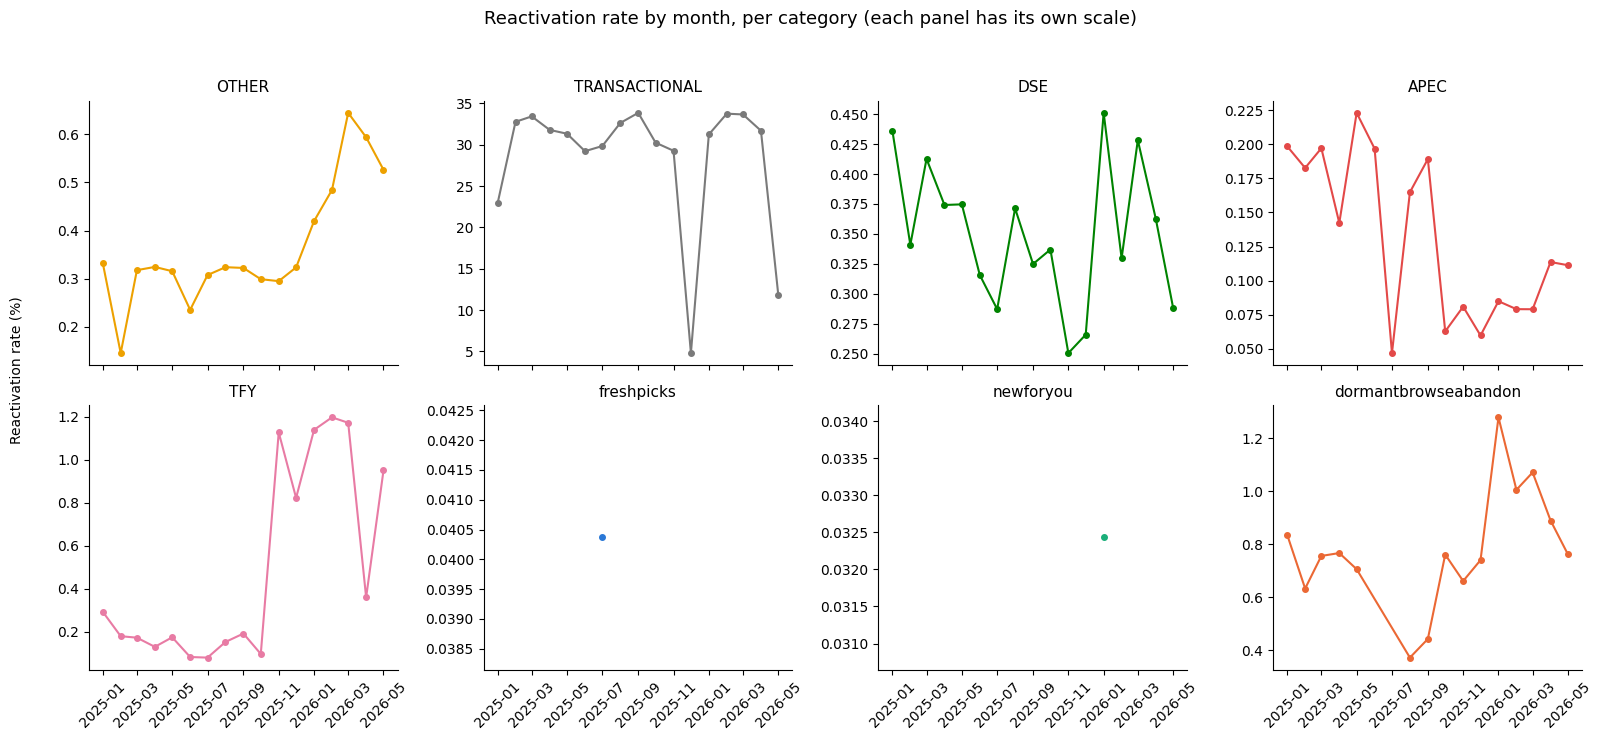

In [10]:
category_order = ['OTHER', 'TRANSACTIONAL', 'DSE', 'APEC', 'TFY', 'freshpicks', 'newforyou', 'dormantbrowseabandon']

fig, axes = plt.subplots(2, 4, figsize=(16, 7.5), sharex=True)
axes = axes.flatten()

for i, cat in enumerate(category_order):
    ax = axes[i]
    cat_df = category_monthly_df[category_monthly_df['campaign_category'] == cat].sort_values('month')
    ax.plot(
        cat_df['month'], cat_df['client_reactivation_rate'] * 100,
        marker='o', markersize=4, linewidth=1.5, color=CATEGORY_COLORS[cat],
    )
    ax.set_title(cat, fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='x', labelrotation=45)

fig.suptitle('Reactivation rate by month, per category (each panel has its own scale)', fontsize=13)
fig.text(0.0, 0.5, 'Reactivation rate (%)', va='center', rotation='vertical')
plt.tight_layout(rect=[0.02, 0, 1, 0.95])
plt.show()

## Limitations to keep in mind

- **Observational, not causal.** Nothing here is randomized. If APEC and non-APEC sends go to different sub-segments of this population, are sent at different frequencies, or through different channels, some of any observed gap could reflect those differences rather than personalization itself.
- **The reactivation metric can overcount.** Because it only requires a qualifying purchase within 2 days of the send — no evidence the client engaged with that specific send — a coincidental, unrelated purchase can get counted as a "reactivation" it wasn't actually caused by. This affects all categories, not just one, but the *size* of that overcount could differ by category depending on how often each one happens to land near an unrelated purchase.
- **Transactional/account-service email is excluded from Part 1, and called out separately in Part 2, because it isn't a marketing lever.** A client only receives one of these (a password reset, an order/Fix status confirmation, an account alert) because they're already taking an action on their own account — the reactivation credited to it reflects the client's own return, not something the send caused. Mixing it into a general "non-APEC" or "OTHER" bucket would substantially inflate that bucket's apparent performance without it reflecting a real, repeatable marketing effect. This effect is expected to be even stronger under this notebook's broader 2-day-purchase-window metric than under a click-through-required metric, since no engagement evidence is needed to count a "reactivation" here.
- **DSE, TFY, newforyou, and freshpicks are inferred categories**, not confirmed personalization. Treat their results as descriptive, not as evidence about embedding-driven personalization specifically.
- **TFY's send volume dropped substantially partway through the window** (see its monthly panel above) — the pooled TFY figure blends a higher-volume earlier period with a much smaller, more recent one, which may not be a like-for-like comparison across the full window.
- **freshpicks and newforyou are each a single one-time send**, not a recurring campaign type — their result is a single data point, not a trend.
- **`END_DATE` is fixed at a date confirmed final for this metric** (45 days past send, per the table owner) — sends more recent than that would be excluded because their flags aren't final yet, not because of any general precaution.